<a href="https://colab.research.google.com/github/JacopoMauro21/progetto_ipcv/blob/main/assignment_two.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Authors:



*   Baseggio Vittorio || 0001243829 || vittorio.baseggio@studio.unibo.it
*   Napoli Luca || 0001232438 || luca.napoli4@studio.unibo.it
*   Mauro Jacopo || 0001245894 || jacopo.mauro4@studio.unibo.it



# **Assignment Module 2: Aircraft Classification**
This notebook tackles fine-grained image classification on the FGVC-Aircraft dataset, where the goal is to distinguish between 100 different aircraft variants, a task made hard by how visually similar many of these variants are to each other. As required by the assignment, we approach the problem in two stages. First, we design and train a convolutional neural network from scratch, built entirely out of standard PyTorch layers rather than an existing architecture, and support our design choices with an ablation study that isolates the contribution of each component (batch normalization, dropout, data augmentation, and the learning rate schedule). Second, we fine-tune a ResNet-18 pretrained on ImageNet, first under the same training setup used for the from-scratch model and then with a set of adjustments better suited to fine-tuning a pretrained network, such as a lower learning rate for the backbone, added weight decay, and training at the network's native input resolution. Throughout, we pay particular attention to overfitting, using the gap between training and validation accuracy as a recurring diagnostic tool when comparing configurations.

In [ ]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torch.utils.data import random_split, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm.notebook import tqdm
import numpy as np
import random
from torchvision.models import resnet18, ResNet18_Weights

def fix_random(seed: int) -> None:
    """Fix all the possible sources of randomness.

    Args:
        seed: the seed to use.
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

fix_random(seed=42)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'device: {device}')

device: cuda


### Downloading the FGVC-Aircraft dataset

We download the dataset via the official PyTorch FGVCAircraft class, using `annotation_level='variant'` as required, loading both the trainval and test splits.

In [ ]:
# transform=None → we get raw PIL images, we handle the transform later
base_trainval = torchvision.datasets.FGVCAircraft(
    root='./data', split='trainval', annotation_level='variant',
    download=True, transform=None)

base_test = torchvision.datasets.FGVCAircraft(
    root='./data', split='test', annotation_level='variant',
    download=True, transform=None)

print(f"Trainval images: {len(base_trainval)} - test: {len(base_test)}")

100%|██████████| 2.75G/2.75G [01:49<00:00, 25.1MB/s]


Trainval images: 6667 - test: 3333


### Checking the classes

We check that the loaded classes correspond to the 100 aircraft variants expected from the dataset.

In [ ]:
class_names = base_trainval.classes
print(len(class_names))

100


### Train/validation split

FGVC-Aircraft doesn't provide a ready-made, independent validation split for the split we chose (`trainval`), so we build our own 80/20 (train/validation) split from `trainval`, using a random permutation with a fixed seed to guarantee reproducibility. The validation set will be used for model selection (choosing the best epoch, comparing configurations in the ablation study), while the test set remains untouched until the final evaluation.

In [ ]:
val_split = 0.2
n = len(base_trainval)
val_size = int(n * val_split)

g = torch.Generator().manual_seed(42)
perm = torch.randperm(n, generator=g).tolist()

val_indices   = perm[:val_size]
train_indices = perm[val_size:]

print(f"Training: {len(train_indices)} - Validation: {len(val_indices)}")

Training: 5334 - Validation: 1333


### Transforms and augmentation

We define the transforms to apply to the images:

- `normalize`: normalization using ImageNet statistics (mean/std), which will also be useful later when fine-tuning a network pretrained on ImageNet (Part 2).
- `pre_resize`: a deterministic resize to 146×146, meant to be applied **only once** and then cached (it's the most expensive operation, so it's worth avoiding repeating it every epoch).
- `train_aug` / `train_aug_full`: light, random data augmentation pipelines (random crop to 128×128, horizontal flip, color jitter, and in `train_aug_full` also `RandomErasing`), to be applied **at every epoch** to increase the variability of the data seen by the model and reduce overfitting. The two variants (with/without erasing) will be used later in the ablation study.
- `eval_aug`: a deterministic pipeline (only center crop + normalization), used for validation and test, where we don't want to introduce randomness.

In [ ]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])

# SLOW and deterministic → applied only ONCE and cached
pre_resize = transforms.Resize((146, 146))

# LIGHT and random → applied at each epoch (augmentation must remain active)
train_aug = transforms.Compose([
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize,
])

# Full augmentation (with erasing)
train_aug_full = transforms.Compose([
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize,
    transforms.RandomErasing(p=0.25),
])

# Evaluation: deterministic
eval_aug = transforms.Compose([
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    normalize,
])

### Dataset with caching of pre-processed images

To avoid repeating the slow JPEG decoding and resizing at every epoch, we define `CachedAircraft`: a custom `Dataset` that, at construction time, applies the "heavy" transform (`pre`, i.e. the resize) only once and keeps the already-resized images in memory. The "light" and random transform (`aug`, i.e. the augmentation) is instead applied on every call to `__getitem__`, so it stays effectively random at each epoch. The `set_aug` method lets us swap the augmentation pipeline at runtime (useful later to reuse the same dataset across different configurations during the ablation study).

In [ ]:
class CachedAircraft(Dataset):
    def __init__(self, base, indices, pre, aug):
        self.aug = aug
        self.cache = []
        for i in tqdm(indices, desc="caching"):
            img, label = base[i]
            self.cache.append((pre(img), label))

    def set_aug(self, aug):
        self.aug = aug

    def __len__(self):
        return len(self.cache)

    def __getitem__(self, idx):
        img, label = self.cache[idx]
        return self.aug(img), label

### Building datasets and dataloaders

We create the cached instances for training, validation, and test (the latter with `eval_aug`, i.e. no augmentation), along with the corresponding `DataLoader`s with a batch size of 128.

In [ ]:
train_ds = CachedAircraft(base_trainval, train_indices, pre_resize, train_aug)
val_ds   = CachedAircraft(base_trainval, val_indices,   pre_resize, eval_aug)
test_ds  = CachedAircraft(base_test, list(range(len(base_test))), pre_resize, eval_aug)

batch_size = 128
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=batch_size, num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=batch_size, num_workers=2)

caching:   0%|          | 0/5334 [00:00<?, ?it/s]

caching:   0%|          | 0/1333 [00:00<?, ?it/s]

caching:   0%|          | 0/3333 [00:00<?, ?it/s]

### Data loading speed test

We measure the time needed to iterate over one epoch of the training set (data transfer only, no training), to verify that caching has actually made data loading fast enough that it won't be a bottleneck during training.

In [ ]:
import time
t = time.time()
for imgs, labels in train_dl:
    imgs = imgs.to(device)
print(f"Only data loading: {time.time()-t:.1f}s")

Only data loading: 6.8s


### Defining the convolutional network "from scratch"

As required by Part 1 of the assignment, we build a CNN by composing standard PyTorch layers (`Conv2d`, `BatchNorm2d`, `ReLU`, `MaxPool2d`, etc.), without using ready-made architectures such as `torchvision.models`. The `SimpleAircraftCNN` architecture consists of:

- 4 convolutional blocks that progressively double the number of channels (64 → 128 → 256 → 512) and halve the spatial resolution via max pooling (128 → 64 → 32 → 16 → 8);
- a final `AdaptiveAvgPool2d` that reduces the feature maps to a 512-dimensional vector, making the network independent of the exact input size;
- a classifier with `Dropout` (regularization) followed by a final `Linear` layer mapping to the 100 classes.

In [ ]:
import torch.nn as nn
import torch

class SimpleAircraftCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),    nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),                                          # 128 -> 64
            nn.Conv2d(64, 128, 3, padding=1),  nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 64 -> 32
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 32 -> 16
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 16 -> 8
            nn.AdaptiveAvgPool2d((1, 1)),                            # -> 512 x 1 x 1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

### Instantiating the model and the optimizer

We create the model and move it to the chosen device. We use `Adam` as the optimizer with learning rate `1e-3` and, in this base configuration, `weight_decay=0.0`.

In [ ]:
model = SimpleAircraftCNN(num_classes=100).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0)

### Helper functions for training and evaluation

We define:

- `ncorrect` / `accuracy`: compute the number of correct predictions and the accuracy on a batch, respectively.
- `train_loop`: the main training/validation loop. At each epoch, it trains the model over all training batches, then evaluates on validation (if provided), keeping track of loss and accuracy for both splits (stored in `history`, which will later be useful for plots). The model with the best validation accuracy is saved to disk (`best_model.pth`) and returned together with the epoch at which it was obtained: this is the *model selection* mechanism (an implicit form of early stopping) we'll use to pick the final weights to evaluate on the test set. If a `scheduler` is passed, the learning rate is updated at every epoch.

In [ ]:
def ncorrect(scores, y):
    y_hat = torch.argmax(scores, -1)
    return (y_hat == y).sum()

def accuracy(scores, y):
    correct = ncorrect(scores, y)
    return correct.true_divide(y.shape[0])

def train_loop(model, train_dl, epochs, opt, val_dl=None, scheduler=None, verbose=False):
    best_val_acc = 0
    best_train = 0
    best_params = []
    best_epoch = -1

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for e in tqdm(range(epochs)):
        model.train()
        train_loss = 0
        train_samples = 0
        train_acc = 0
        for train_data in train_dl:
            imgs = train_data[0].to(device)
            labels = train_data[1].to(device)
            scores = model(imgs)
            loss = F.cross_entropy(scores, labels, reduction="sum")
            train_loss += loss.item()
            train_samples += imgs.shape[0]
            train_acc += ncorrect(scores, labels).item()

            opt.zero_grad()
            loss.backward()
            opt.step()

        train_acc /= train_samples
        train_loss /= train_samples

        model.eval()
        with torch.no_grad():
            val_loss = 0
            val_samples = 0
            val_acc = 0
            if val_dl is not None:
                for val_data in val_dl:
                    imgs = val_data[0].to(device)
                    labels = val_data[1].to(device)
                    val_scores = model(imgs)
                    val_loss += F.cross_entropy(val_scores, labels, reduction="sum").item()
                    val_samples += imgs.shape[0]
                    val_acc += ncorrect(val_scores, labels).item()
                val_acc /= val_samples
                val_loss /= val_samples

            if val_dl is None or val_acc > best_val_acc:
                best_val_acc = val_acc if val_dl is not None else 0
                best_train = train_acc
                best_params = model.state_dict()
                torch.save(best_params, "best_model.pth")
                best_epoch = e

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss if val_dl is not None else None)
        history["val_acc"].append(val_acc if val_dl is not None else None)

        if verbose and e % 5 == 0:
            tqdm.write(f"Epoch {e}: train loss {train_loss:.3f} - train acc {train_acc:.3f}" + ("" if val_dl is None else f" - valid loss {val_loss:.3f} - valid acc {val_acc:.3f}"))

    if verbose and val_dl is not None:
        tqdm.write(f"Best epoch {best_epoch}, best acc {best_val_acc}, best train {best_train}")

    return best_val_acc, best_params, best_epoch, best_train, history

### Training the base model (Part 1)

We train `SimpleAircraftCNN` for 100 epochs using the Adam optimizer and augmentation pipeline defined earlier, with a `CosineAnnealingLR` scheduler that gradually decreases the learning rate following a cosine curve over the whole training run (this helps convergence in the final phases). The checkpoint with the best validation accuracy is kept as our final Part 1 model, which will serve both as the `full_model` baseline in the ablation study and as the reference configuration for Part 2A.

In [ ]:
epochs = 100
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_val_acc, best_params, best_epoch, best_train, _ = train_loop(
    model,
    train_dl,
    epochs,
    optimizer,
    val_dl,
    scheduler=scheduler,
    verbose=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0: train loss 4.646 - train acc 0.020 - valid loss 4.504 - valid acc 0.030
Epoch 5: train loss 4.022 - train acc 0.077 - valid loss 4.087 - valid acc 0.084
Epoch 10: train loss 3.431 - train acc 0.142 - valid loss 3.762 - valid acc 0.098
Epoch 15: train loss 3.053 - train acc 0.217 - valid loss 3.385 - valid acc 0.171
Epoch 20: train loss 2.698 - train acc 0.297 - valid loss 3.006 - valid acc 0.229
Epoch 25: train loss 2.400 - train acc 0.356 - valid loss 2.981 - valid acc 0.248
Epoch 30: train loss 2.126 - train acc 0.422 - valid loss 2.582 - valid acc 0.323
Epoch 35: train loss 1.895 - train acc 0.475 - valid loss 2.311 - valid acc 0.381
Epoch 40: train loss 1.706 - train acc 0.530 - valid loss 2.370 - valid acc 0.388
Epoch 45: train loss 1.525 - train acc 0.579 - valid loss 2.042 - valid acc 0.470
Epoch 50: train loss 1.366 - train acc 0.619 - valid loss 2.115 - valid acc 0.460
Epoch 55: train loss 1.254 - train acc 0.651 - valid loss 1.967 - valid acc 0.492
Epoch 60: train lo

### Evaluation on the test set

We reload the weights of the best model (based on validation accuracy) and compute the final accuracy on the test set, which is the metric required by the assignment to check that we've reached the ~50% accuracy target.


In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

correct = total = 0
with torch.no_grad():
    for imgs, labels in test_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += ncorrect(model(imgs), labels).item()
        total += imgs.shape[0]

print(f"Test accuracy: {correct/total:.4f}")

Test accuracy: 0.5611


### Ablation study

As required by the assignment, we now run an ablation study to show that each design choice in our architecture (batchnorm, dropout, augmentation, scheduler) has a positive effect on performance.

### Persistent storage on Google Drive

Since the ablation study requires training several models (hence long computation times on Colab, where sessions can be interrupted), we mount Google Drive and create a dedicated folder to progressively save the results of the different configurations, so that we can resume work without having to rerun experiments that were already completed.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/ipcv_ablation_results'
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


### Utilities to save/load ablation study results

`load_existing_results` loads (if present) the results already computed from a JSON file; `save_result` saves the "light" results (accuracy, gap, etc.) in JSON and the full history (loss/accuracy per epoch) separately in a pickle file. This incremental checkpointing mechanism avoids retraining configurations that have already been completed in case of interruptions.

In [ ]:
import json
import pickle

RESULTS_FILE = os.path.join(SAVE_DIR, "ablation_results.json")
HISTORY_DIR = os.path.join(SAVE_DIR, "histories")
os.makedirs(HISTORY_DIR, exist_ok=True)

def load_existing_results():
    if os.path.exists(RESULTS_FILE):
        with open(RESULTS_FILE, "r") as f:
            return json.load(f)
    return {}

def save_result(name, result):
    result_light = {k: v for k, v in result.items() if k != "history"}

    existing = load_existing_results()
    existing[name] = result_light
    with open(RESULTS_FILE, "w") as f:
        json.dump(existing, f, indent=2)

    with open(os.path.join(HISTORY_DIR, f"{name}.pkl"), "wb") as f:
        pickle.dump(result["history"], f)

### Parametric version of the network for the ablation study

We define `SimpleAircraftCNN_ablation`, a variant of `SimpleAircraftCNN` in which some components (batch normalization, dropout) can be turned on or off via flags (`use_bn`, `use_dropout`), replacing them with `nn.Identity()` when disabled. This lets us reuse the same architecture to test the effect of each component, as required by the ablation study.

In [ ]:
class SimpleAircraftCNN_ablation(nn.Module):
    def __init__(self, num_classes=100, use_bn=True, use_dropout=True, dropout_p=0.5):
        super().__init__()
        def bn(ch):
            return nn.BatchNorm2d(ch) if use_bn else nn.Identity()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),    bn(64),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),  bn(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), bn(256), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1), bn(512), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p) if use_dropout else nn.Identity(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

### Generic evaluation function

A reusable `evaluate` function that computes the accuracy of a model on any dataloader (it will be used both in the ablation study and in Part 2).

In [ ]:
def evaluate(model, dl):
  model.eval()
  correct = total = 0
  with torch.no_grad():
      for imgs, labels in dl:
          imgs, labels = imgs.to(device), labels.to(device)
          correct += ncorrect(model(imgs), labels).item()
          total += imgs.shape[0]
  accuracy = correct/total
  return accuracy

### Ablation study configurations

We define a base configuration (`BASE_CONFIG`, corresponding to the full/best model found) and a dictionary of alternative configurations, each obtained by removing (or disabling) a single component relative to the base configuration:

- `no_batchnorm`: removes batch normalization;
- `no_dropout`: removes dropout;
- `no_augmentation`: fully disables data augmentation (uses the deterministic transforms even during training);
- `no_erasing`: keeps augmentation but removes `RandomErasing`;
- `no_scheduler`: removes the learning rate scheduler.

By comparing the performance of each variant against the full model, we can demonstrate the positive impact of each individual design choice, as required by the assignment.

In [ ]:
BASE_CONFIG = dict(
    use_bn=True, use_dropout=True, dropout_p=0.5,
    use_augmentation=True, use_erasing=True,
    weight_decay=0.0, use_scheduler=True,
)

ablations = {
    "full_model":        BASE_CONFIG,
    "no_batchnorm":      {**BASE_CONFIG, "use_bn": False},
    "no_dropout":        {**BASE_CONFIG, "use_dropout": False},
    "no_augmentation":   {**BASE_CONFIG, "use_augmentation": False, "use_erasing": False},
    "no_erasing":        {**BASE_CONFIG, "use_erasing": False},
    "no_scheduler":      {**BASE_CONFIG, "use_scheduler": False},
}

### Selecting the augmentation pipeline based on the configuration

A helper function that, given a configuration dictionary, returns the correct augmentation pipeline (none, light, or full with erasing).

In [ ]:
def select_aug(config):
    if not config["use_augmentation"]:
        return eval_aug
    return train_aug_full if config["use_erasing"] else train_aug

### Training function for a single ablation configuration

`run_ablation` fixes the seed, sets up the augmentation and the model according to the given configuration, trains with `train_loop` (using the same validation set as the other runs for a fair comparison), loads the best weights, and computes the accuracy on the test set. It also computes the `gap` between training and test accuracy, an indicator of how much that configuration overfits.

In [ ]:
def run_ablation(name, config, epochs=100, seed=42):
    torch.manual_seed(seed)

    train_ds.set_aug(select_aug(config))
    train_dl_ab = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)

    model = SimpleAircraftCNN_ablation(
        num_classes=100,
        use_bn=config["use_bn"],
        use_dropout=config["use_dropout"],
        dropout_p=config["dropout_p"],
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3,
                                  weight_decay=config["weight_decay"])
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
                 if config["use_scheduler"] else None)

    best_val_acc, best_params, best_epoch, best_train, history = train_loop(
        model, train_dl_ab, epochs, optimizer, val_dl,
        scheduler=scheduler, verbose=False
    )

    model.load_state_dict(best_params)
    test_acc = evaluate(model, test_dl)

    gap = best_train - test_acc

    return {"name": name, "test_acc": test_acc, "train_acc": best_train,
            "gap": gap, "best_epoch": best_epoch, "history": history}

### Running all ablation configurations

We loop over all the configurations defined in `ablations`: if a configuration has already been completed previously (and saved on Drive), we simply reload its results; otherwise we train it from scratch and save the results incrementally. This makes the process robust to any interruptions of the Colab session.

In [ ]:
existing_results = load_existing_results()
results = []

for name, cfg in ablations.items():
    if name in existing_results:
        print(f"[SKIP] '{name}' already completed, loading from save.")
        r = existing_results[name]
        with open(os.path.join(HISTORY_DIR, f"{name}.pkl"), "rb") as f:
            r["history"] = pickle.load(f)
        results.append(r)
        continue

    print(f"[RUN] Starting ablation: {name}")
    r = run_ablation(name, cfg)
    save_result(name, r)
    results.append(r)
    print(f"[DONE] '{name}': test_acc={r['test_acc']:.4f}, gap={r['gap']:.4f}")

[SKIP] 'full_model' already completed, loading from save.
[SKIP] 'no_batchnorm' already completed, loading from save.
[SKIP] 'no_dropout' already completed, loading from save.
[SKIP] 'no_augmentation' already completed, loading from save.
[SKIP] 'no_erasing' already completed, loading from save.
[SKIP] 'no_scheduler' already completed, loading from save.


### Summary table and bar charts of the ablation results

We build a DataFrame with the results of all configurations (sorted with the full model on top, then by decreasing accuracy) and produce two side-by-side plots:

1. a horizontal bar chart with the test accuracy of each configuration, with a dashed line marking the full model's reference level;
2. a grouped bar chart comparing train accuracy and test accuracy for each configuration, annotated with the gap (useful for spotting which components reduce overfitting the most).

Finally, we print a text summary table with all the metrics.

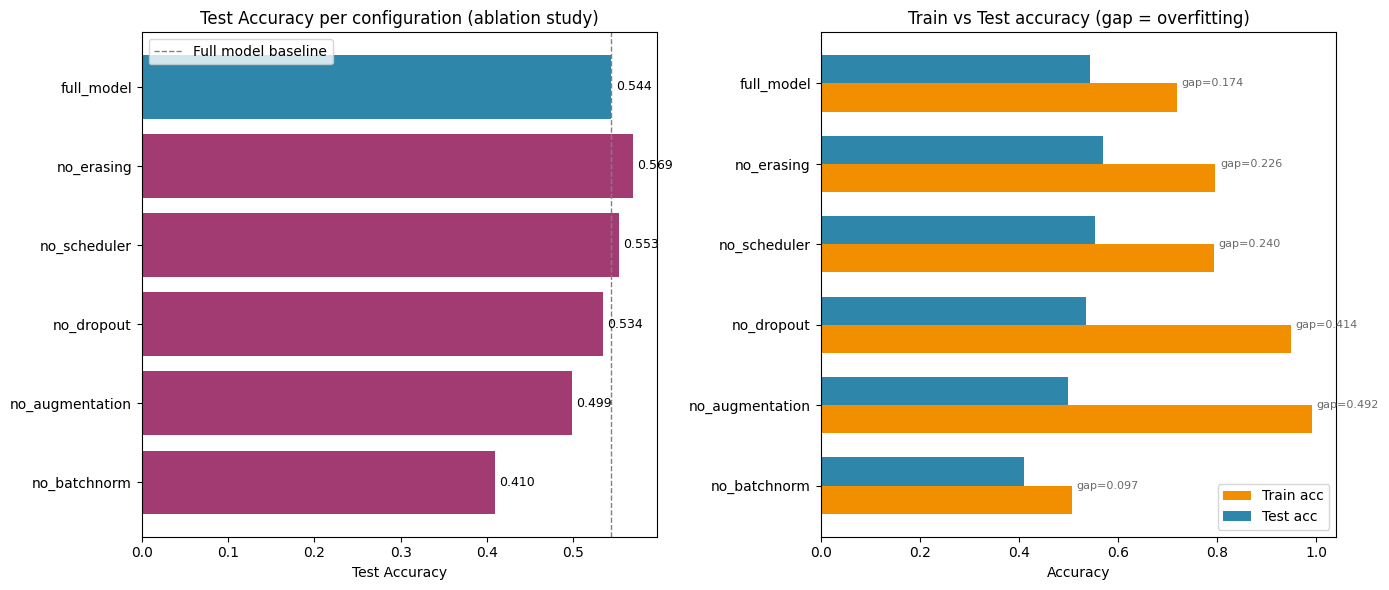

           name  test_acc  train_acc    gap  best_epoch
     full_model    0.5443     0.7184 0.1742          86
     no_erasing    0.5692     0.7955 0.2263          97
   no_scheduler    0.5527     0.7930 0.2404          91
     no_dropout    0.5344     0.9483 0.4139          90
no_augmentation    0.4986     0.9908 0.4922          87
   no_batchnorm    0.4095     0.5066 0.0970          90


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.DataFrame(results)

# order by putting full_model at the top, then others by decreasing test_acc
df["is_full"] = df["name"] == "full_model"
df = df.sort_values(["is_full", "test_acc"], ascending=[False, False]).drop(columns="is_full")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ["#2E86AB" if n == "full_model" else "#A23B72" for n in df["name"]]

# --- Plot 1: Test accuracy per configuration ---
ax = axes[0]
bars = ax.barh(df["name"], df["test_acc"], color=colors)
ax.set_xlabel("Test Accuracy")
ax.set_title("Test Accuracy per configuration (ablation study)")
ax.axvline(df.loc[df["name"] == "full_model", "test_acc"].values[0],
           color="gray", linestyle="--", linewidth=1, label="Full model baseline")
ax.legend()
ax.invert_yaxis()  # full_model at the top
for bar, val in zip(bars, df["test_acc"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.3f}",
            va="center", fontsize=9)

# --- Plot 2: Train/Test accuracy side by side + gap ---
ax = axes[1]
y = np.arange(len(df))
height = 0.35
ax.barh(y + height/2, df["train_acc"], height=height, label="Train acc", color="#F18F01")
ax.barh(y - height/2, df["test_acc"], height=height, label="Test acc", color="#2E86AB")
ax.set_yticks(y)
ax.set_yticklabels(df["name"])
ax.set_xlabel("Accuracy")
ax.set_title("Train vs Test accuracy (gap = overfitting)")
ax.invert_yaxis()
ax.legend()

# annotate the gap next to each row
for i, (train_a, gap) in enumerate(zip(df["train_acc"], df["gap"])):
    ax.text(train_a + 0.01, i, f"gap={gap:.3f}", va="center", fontsize=8, color="dimgray")

plt.tight_layout()
plt.savefig("ablation_results.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Ordered summary table ---
print(df[["name", "test_acc", "train_acc", "gap", "best_epoch"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

This ablation study aims to explain the design choices we made for the architecture, the hyperparameters and the training techniques used for this simple image classifier.

Some of these choices were made for improving the overall accuracy of the Neural Network, in particular:


*   Batchnorm: the batch-normalization layer, as we can see, improves by almost 0.15 points the accuracy of the model. Even if its role inside the networks architecture isn't still completely understood, as per literature, empirically its presence is clear and helpful and a network without this layer drop significantly in performance.
*   Image augmentation: horizontal flipping, random cropping (to 128x128 images), changing brightness and contrast and applying random erasing (whose effects will be analyzed more in detail after), all of these techniques improve significantly the classifier performance. The training set is, in fact, really small for traning a network from scratch and Image Augmentation helps test accuracy by 0.05 points and also have a clear regularization effect, reducing drastically the overfitting that the network otherwise would have.


Other choices, instead, are made in order to obtain a network that doesn't overfit too much over a such small training dataset. As explained above, image augmentation is one of these techniques, but other than that, we also use:


*   Dropout: the absence of this tecnique creates a network that achieves comparable results in term of overall test accuracy (the minimal error may be due to noise), but by analyzing the gap in values between test and training accuracy we can clearly notice how this method is such a powerful regularizer, obtaining over the double compared to the network that use dropout, clearly overfitting it.
*   Learning rate scheduler: a network trained without a learning rate scheduler achieves comparable results to the full network in terms of test accuracy, with respect to a small difference due to noise, but has significantly increased training accuracy, almost by 0.10 points (a total of about 0.80). This can be interpreted as a signal for a network that generalizes its results in a suboptimal way.
*   Random erasing: a network trained with images that don't have random erasing achieves similar results, in terms of accuracy values, to the network  trained with no LR Scheduler. In this particular case, we wanted to focus our attention on the effects produces by a single Image Augmentation technique. We wanted to particularly emphatise how the non-application of this method alone produces a significant increment in training accuracy, which could be interpreted in this case as a sign of overfitting because the increment in test accuracy isn't nearly as big.


### Training/validation curves compared across configurations

`plot_training_curves` overlays, for a chosen metric (e.g. `val_acc` or `train_acc`), the epoch-by-epoch trend of all tested configurations, making it easy to see at a glance which variants converge faster or reach a higher plateau.

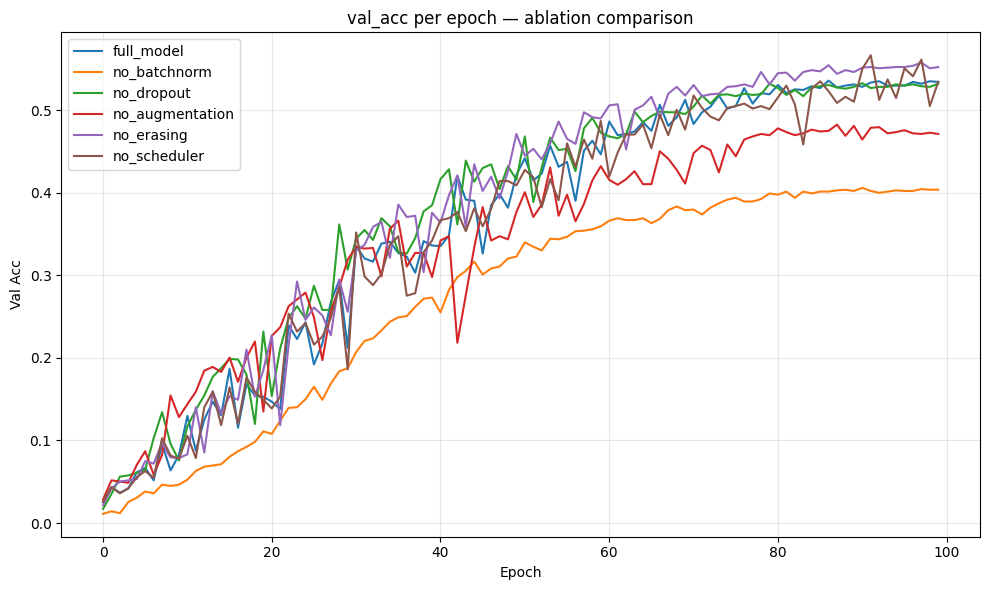

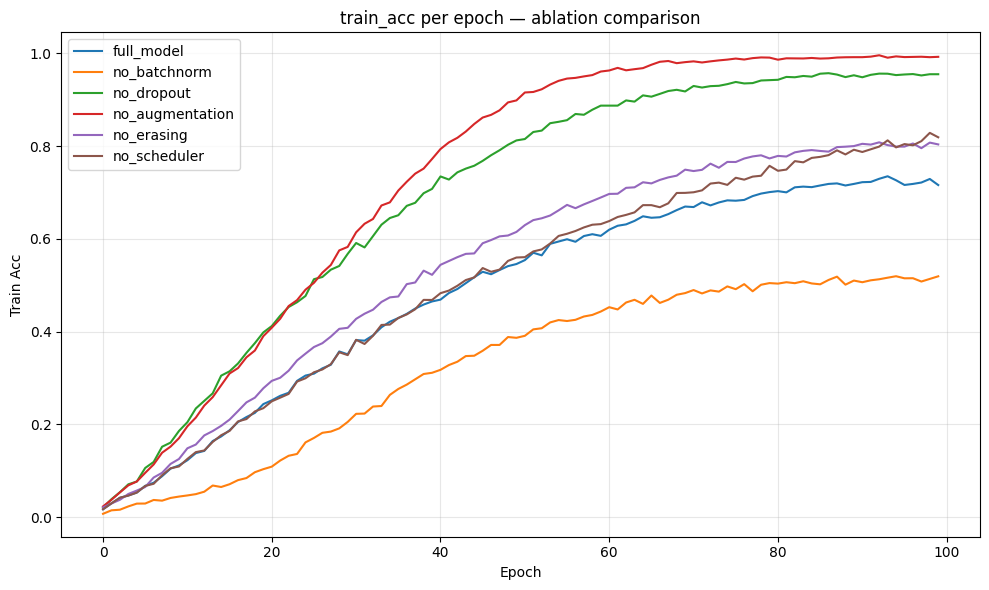

In [ ]:
def plot_training_curves(results, metric="val_acc", title=None):
    plt.figure(figsize=(10, 6))
    for r in results:
        epochs_range = range(len(r["history"][metric]))
        plt.plot(epochs_range, r["history"][metric], label=r["name"])
    plt.xlabel("Epoch")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(title or f"{metric} per epoch — ablation comparison")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"ablation_{metric}_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_training_curves(results, metric="val_acc")
plot_training_curves(results, metric="train_acc")

In these two graphs we can see 2 different phenomena:


*   In the first graph, where we compare validation accuracy of the models over the epochs, we can clearly see how some training techniques and hyperparameter settings have an influence in producing smooth and stable learning curves. Networks without a Learning Rate Scheduler and without Data Augmentation, in particular, produce learning curves with higher spikes and drops with respect to the others and so their training phase is clearly less stable than all the others. This is expected because the network without data augmentation has a lot less data to train on and so its first epochs espetially will be less stable. On the other hand, a network with a fixed learning rate will never achieve a real minimum in the gradient space, so every epoch will have a different validation accuracy. That's why we can see spikes in its curve even when all other networks have achieve a smoother path.
*   In the second graph, we analize the training accuracy of all the different networks in the ablation study, with the number of epochs in the horizontal axis. As we can see, there are clearly different groups of networks. The network that underfit the data is the one with no batchnorm layers. The ones that overfit very quickly are the networks with no data augmentation and with no dropout, some of the most powerful regularization techniques. Finally, the ones that achieve better training accuracy than the full model, but can be considered overfitting because they haven't clear improvements in the testing accuracy are the ones that are more similar to it, so networks without random erasing and without LR scheduler that, for the motivations explained above, are suboptimal networks.



### Train vs validation curve of the full model

`plot_train_vs_val` shows, for a single run, the training and validation accuracy over time, highlighting the gap between the two with a shaded area (a wide and growing gap is typically a sign of overfitting). Here we apply it to the full model (`full_model`) identified in the ablation study, which represents the best model from Part 1. It's the one  that achieves good enough results and where the gap between training and validation accuracy is minimal.

In [ ]:
def plot_train_vs_val(result, title=None):
    h = result["history"]
    epochs_range = range(len(h["train_acc"]))
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, h["train_acc"], label="Train acc")
    plt.plot(epochs_range, h["val_acc"], label="Val acc")
    plt.fill_between(epochs_range,
                      h["train_acc"], h["val_acc"],
                      alpha=0.15, color="red", label="Gap")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title or f"{result['name']}: train vs val accuracy over time")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

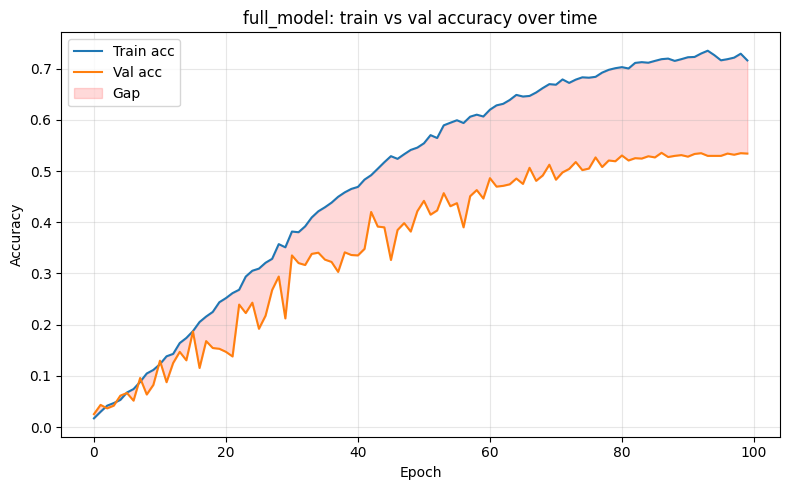

In [ ]:
full_model_result = next(r for r in results if r["name"] == "full_model")
plot_train_vs_val(full_model_result)

## Part 2
We now move to Part 2 of the assignment: instead of designing a network from scratch, we fine-tune a pretrained ResNet-18 (ImageNet-1K, V1 weights) on the same `FGVCAircraft` classification task. We first fine-tune it with the same hyperparameters used in Part 1 (2A), then adjust them to try to reach the ~70% test accuracy target (2B).

### Part 2A — Fine-tuning ResNet-18 with the same hyperparameters as Part 1

We load the `resnet18` model pretrained on ImageNet-1K (weights `IMAGENET1K_V1`) provided by `torchvision.models`, and replace the last fully-connected layer (`model.fc`) with a new one that outputs 100 classes (the FGVC-Aircraft classes), leaving the rest of the network unchanged. As required by point 2A of the assignment, we use exactly the same training hyperparameters as in Part 1 (Adam, lr=1e-3, weight_decay=0.0, 100 epochs, cosine annealing scheduler), so that in point 2B we can isolate the effect of the hyperparameter changes alone.



In [ ]:
## 2A

fix_random(seed=42)

# --- model ---
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 100)
model = model.to(device)

# --- same hyperparameters used in Part 1 ---
epochs = 100
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# Reset of train_ds since it was modified during training
train_ds.set_aug(train_aug_full)

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)

best_val_acc, best_params, best_epoch, best_train, history = train_loop(
    model, train_dl, epochs, optimizer, val_dl, scheduler=scheduler, verbose=True
)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0: train loss 3.831 - train acc 0.122 - valid loss 4.328 - valid acc 0.075
Epoch 5: train loss 1.193 - train acc 0.642 - valid loss 1.744 - valid acc 0.502
Epoch 10: train loss 0.661 - train acc 0.792 - valid loss 1.616 - valid acc 0.577
Epoch 15: train loss 0.448 - train acc 0.859 - valid loss 1.587 - valid acc 0.598
Epoch 20: train loss 0.309 - train acc 0.906 - valid loss 1.567 - valid acc 0.638
Epoch 25: train loss 0.232 - train acc 0.932 - valid loss 1.706 - valid acc 0.614
Epoch 30: train loss 0.222 - train acc 0.930 - valid loss 1.759 - valid acc 0.616
Epoch 35: train loss 0.166 - train acc 0.950 - valid loss 1.545 - valid acc 0.658
Epoch 40: train loss 0.127 - train acc 0.963 - valid loss 1.523 - valid acc 0.668
Epoch 45: train loss 0.118 - train acc 0.964 - valid loss 1.440 - valid acc 0.695
Epoch 50: train loss 0.088 - train acc 0.974 - valid loss 1.485 - valid acc 0.690
Epoch 55: train loss 0.077 - train acc 0.979 - valid loss 1.410 - valid acc 0.696
Epoch 60: train lo

### Training/validation curves for model 2A

We visualize the train and validation accuracy trend of the "vanilla" ResNet-18 fine-tuning, useful as a baseline to diagnose potential issues (e.g. overfitting) before introducing the changes of Part 2B.

Test accuracy 2A: 0.7408


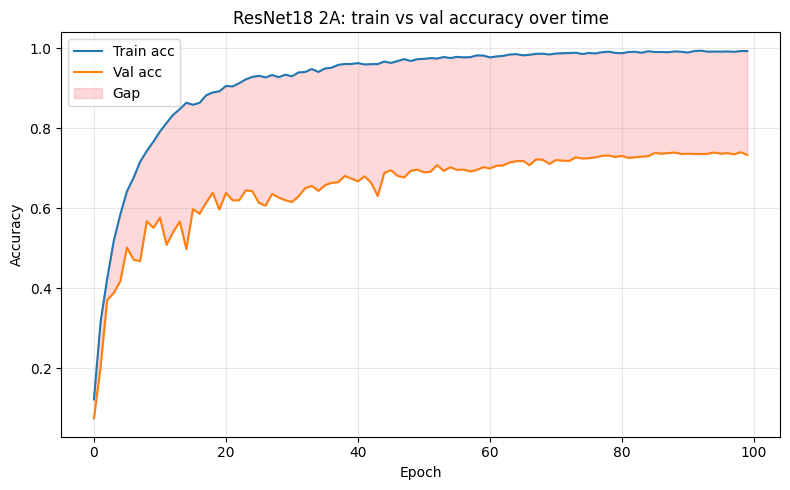

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
test_acc_2a = evaluate(model, test_dl)
print(f"Test accuracy 2A: {test_acc_2a:.4f}")

resnet_ft_result = {
    "name": "ResNet18 2A",
    "history": history
}
plot_train_vs_val(resnet_ft_result)

The fine-tuning of ResNet-18 converges much more quickly than the `SimpleAircraftCNN` network from Part 1: by around epoch 20, the validation accuracy is already about 0.64—a value that the from-scratch network does not even reach by the end of training (best val acc 0.566). This confirms the benefit of pretraining on ImageNet as an initialization.

However, when using exactly the same hyperparameters as in Part 1 (no weight decay, a single learning rate for the entire network, 128×128 resolution), the model overfits: the training accuracy reaches 0.993, while the validation and test accuracy hover around 0.70–0.74 (best epoch 98, val acc 0.740 - final test accuracy 0.741), with a gap of about 25 points that remains wide for most of the training. This clearly shows that hyperparameters designed to train a small CNN from scratch are not suitable for fine-tuning a much larger pretrained network, which is why the changes introduced in Part 2B were necessary.

### New transforms at 224×224 resolution

For Part 2B we define transforms at a higher resolution (224×224, the "native" resolution ResNet-18 was pretrained on with ImageNet, [[Deep Residual Learning for Image Recognition](https://openaccess.thecvf.com/content_cvpr_2016/html/He_Deep_Residual_Learning_CVPR_2016_paper.html)]), keeping the same type of augmentation (random crop, flip, color jitter, random erasing) used before, so as to isolate the effect of resolution/hyperparameters alone relative to Part 2A.

In addition, since 2A showed clear signs of overfitting (a persistent train/validation accuracy gap), we introduce a non-zero weight decay in this stage, to be applied through the optimizer (see the model/optimizer setup below) as an explicit regularizer that penalizes large weights and should help close that gap, [[Dive into Deep Learning, "Weight Decay", d2l.ai](https://d2l.ai/chapter_linear-regression/weight-decay.html)].

In [ ]:

pre_resize_224 = transforms.Resize((256, 256))

train_aug_224 = transforms.Compose([
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize,
    transforms.RandomErasing(p=0.25),
])

eval_aug_224 = transforms.Compose([
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize,
])

### Re-caching the datasets at 224px

We rebuild the cached datasets and dataloaders at the new resolution. We reduce the batch size from 128 to 64, since 224×224 images take up roughly three times the memory of the 128×128 images used so far.

In [ ]:

train_ds_224 = CachedAircraft(base_trainval, train_indices, pre_resize_224, train_aug_224)
val_ds_224   = CachedAircraft(base_trainval, val_indices,   pre_resize_224, eval_aug_224)
test_ds_224  = CachedAircraft(base_test, list(range(len(base_test))), pre_resize_224, eval_aug_224)

batch_size_224 = 64

train_dl_224 = DataLoader(train_ds_224, batch_size=batch_size_224, shuffle=True, num_workers=2)
val_dl_224   = DataLoader(val_ds_224,   batch_size=batch_size_224, num_workers=2)
test_dl_224  = DataLoader(test_ds_224,  batch_size=batch_size_224, num_workers=2)

print(f"Cached at 224px — train: {len(train_ds_224)}, val: {len(val_ds_224)}, test: {len(test_ds_224)}")

caching:   0%|          | 0/5334 [00:00<?, ?it/s]

caching:   0%|          | 0/1333 [00:00<?, ?it/s]

caching:   0%|          | 0/3333 [00:00<?, ?it/s]

Cached at 224px — train: 5334, val: 1333, test: 3333


### Model and hyperparameter setup for Part 2B

We create a new pretrained ResNet-18 model (with `fc` replaced as in 2A) and set up the hyperparameter changes motivated in the previous cell:

- we separate the pretrained backbone's parameters from those of the new `fc` layer, so we can assign them different learning rates (`2e-4` for the backbone, `1e-3` for the classifier);
- we use `AdamW` instead of `Adam`, with weight decay `5e-4`;
- we reduce the number of epochs to 60 (thanks to pretraining, convergence is faster) and adjust the cosine annealing scheduler accordingly.

In [ ]:
fix_random(seed=42)

model_2b = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model_2b.fc = nn.Linear(model_2b.fc.in_features, 100)
model_2b = model_2b.to(device)

backbone_params = [p for n, p in model_2b.named_parameters() if not n.startswith("fc")]
fc_params       = [p for n, p in model_2b.named_parameters() if n.startswith("fc")]

epochs = 60
optimizer_2b = torch.optim.AdamW([
    {"params": backbone_params, "lr": 2e-4},
    {"params": fc_params,       "lr": 1e-3},
], weight_decay=1e-4)

scheduler_2b = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_2b, T_max=epochs)

### Training model 2B

We run training with `train_loop`, using the 224px dataloaders and the hyperparameters just defined.

The number of training epochs was also reduced from 100 to 60. Since fine-tuning starts from ImageNet-pretrained weights, convergence is considerably faster than training from scratch, and the validation accuracy had already plateaued well before epoch 60.

In [ ]:
best_val_acc_2b, best_params_2b, best_epoch_2b, best_train_2b, history_2b = train_loop(
    model_2b, train_dl_224, epochs, optimizer_2b, val_dl_224,
    scheduler=scheduler_2b, verbose=True)

print(f"Best epoch: {best_epoch_2b}, best val acc: {best_val_acc_2b:.4f}, best train acc: {best_train_2b:.4f}")

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 0: train loss 3.502 - train acc 0.205 - valid loss 2.306 - valid acc 0.366
Epoch 5: train loss 0.463 - train acc 0.876 - valid loss 1.005 - valid acc 0.703
Epoch 10: train loss 0.201 - train acc 0.948 - valid loss 1.059 - valid acc 0.724
Epoch 15: train loss 0.150 - train acc 0.959 - valid loss 0.994 - valid acc 0.725
Epoch 20: train loss 0.098 - train acc 0.975 - valid loss 0.922 - valid acc 0.761
Epoch 25: train loss 0.083 - train acc 0.976 - valid loss 1.081 - valid acc 0.761
Epoch 30: train loss 0.066 - train acc 0.981 - valid loss 0.983 - valid acc 0.762
Epoch 35: train loss 0.052 - train acc 0.985 - valid loss 0.879 - valid acc 0.779
Epoch 40: train loss 0.035 - train acc 0.990 - valid loss 0.875 - valid acc 0.784
Epoch 45: train loss 0.034 - train acc 0.990 - valid loss 0.797 - valid acc 0.791
Epoch 50: train loss 0.023 - train acc 0.994 - valid loss 0.808 - valid acc 0.797
Epoch 55: train loss 0.023 - train acc 0.994 - valid loss 0.804 - valid acc 0.803
Best epoch 46, bes

### Final evaluation of model 2B

We reload the best weights (based on validation accuracy) and evaluate the accuracy on the test set: this is the final result of Part 2B, which should be close to the ~70% required by the assignment. Finally, we plot the training/validation curves to confirm that the changes actually reduced the overfitting gap observed in 2A.

Test accuracy 2B: 0.8053


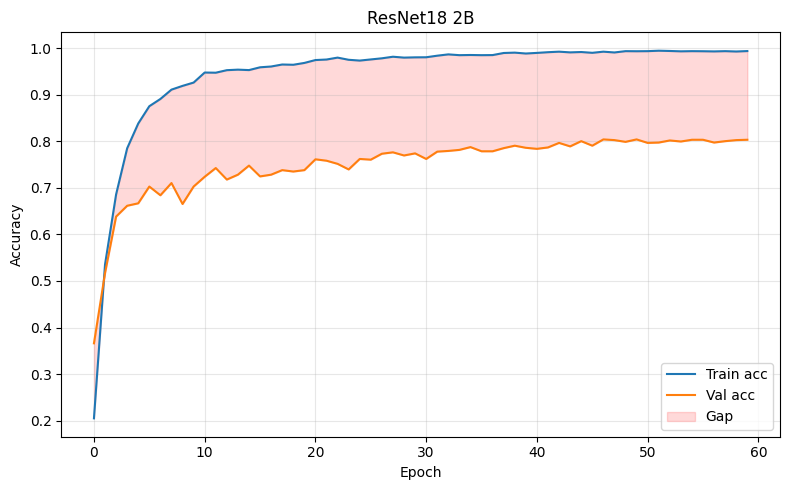

In [ ]:
model_2b.load_state_dict(torch.load("best_model.pth"))
test_acc_2b = evaluate(model_2b, test_dl_224)
print(f"Test accuracy 2B: {test_acc_2b:.4f}")

plot_train_vs_val({"name": "ResNet18 2B", "history": history_2b}, title="ResNet18 2B")

The changes introduced in Part 2B—differentiated learning rates for the backbone (2e-4) and classifier (1e-3), non-zero weight decay (5e-4) using AdamW, and the native resolution of ResNet-18 (224×224)—improve both convergence speed and generalization. The validation accuracy already reaches approximately 0.70 at epoch 5 (compared to the ~45 epochs required in 2A), and the best value (0.804) is achieved at epoch 46 out of 60—despite 40 fewer epochs than in 2A, the model converges sooner and surpasses the plateau previously reached. The training/validation gap narrows from about 25 points in 2A to about 19 points in 2B (training acc 0.993, validation acc 0.804), this also translates well in the difference between testing accuracy in 2A and 2B, as the gap between the two is, as expected, very similar to the gap between the two validation accuracies. Overall, this is a sign that weight decay and the reduced learning rate on the backbone are effectively acting as regularizers, even though some overfitting remains.
